# Information-Adaptive Latent Distributional Robustness for Climate-Transition Portfolio Choice

<p align="center">
  <img src="https://img.shields.io/badge/Python-3.10%2B-3776AB?logo=python&logoColor=white" alt="Python">
  <img src="https://img.shields.io/badge/PyTorch-CUDA-EE4C2C?logo=pytorch&logoColor=white" alt="PyTorch CUDA">
  <img src="https://img.shields.io/badge/NVIDIA-CUDA-76B900?logo=nvidia&logoColor=white" alt="NVIDIA CUDA">
  <img src="https://img.shields.io/badge/Reproducibility-Enabled-success" alt="Reproducible">
  <img src="https://img.shields.io/badge/Research-Code-blue" alt="Research Code">
</p>

## Overview

This repository contains the computational implementation accompanying the paper

> **Information-Adaptive Latent Distributional Robustness for Climate-Transition Portfolio Choice**

The code reproduces the two main computational components of the study:

1. the **Controlled Simulation Study**, designed to evaluate the analytical mechanisms of information-adaptive latent distributional robustness under a controlled data-generating process;

In [1]:
# Imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import matplotlib as mpl

from matplotlib.ticker import MaxNLocator, FormatStrFormatter

from matplotlib.lines import Line2D

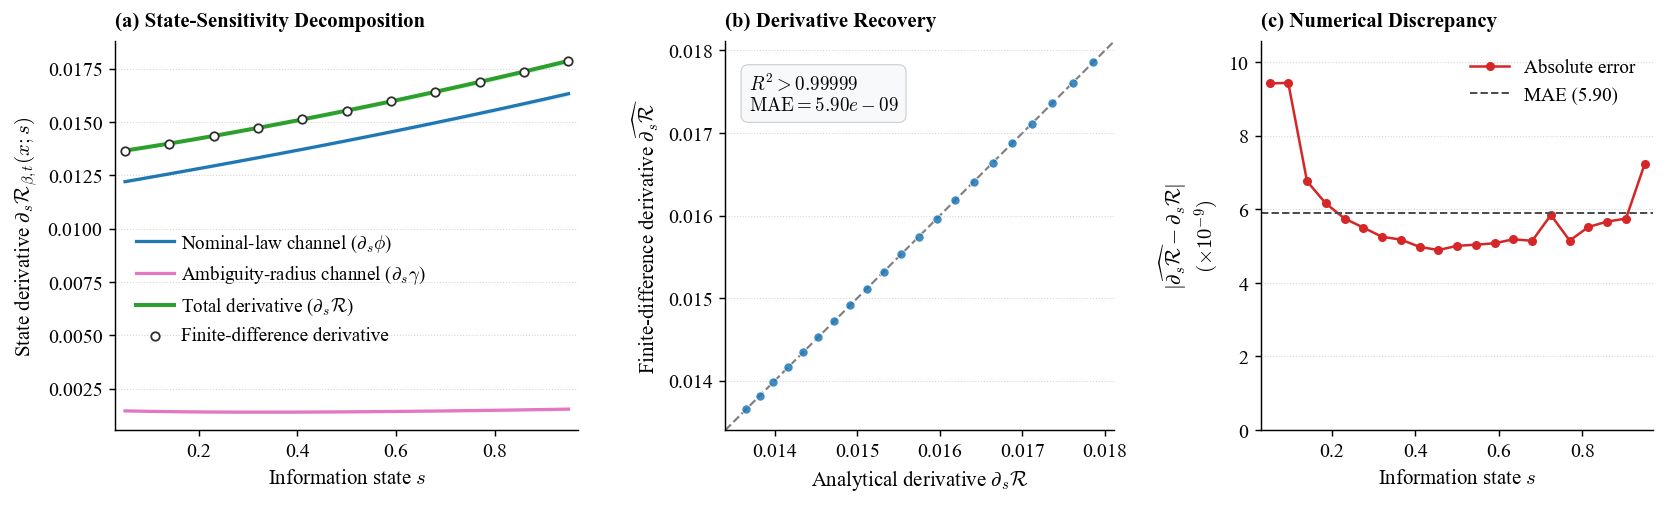

In [2]:
# -------------------------------------------------------------------------
# Figure 1
# -------------------------------------------------------------------------


data_fig1 = pd.read_csv(r"C:\Users\fredy\Downloads\Results_Section4_V5_Full\figure_csv\figure_1_data.csv")

d = (data_fig1.loc[data_fig1["design"].eq("D_phi+gamma")]
     .sort_values("state")
     .reset_index(drop=True)
     .copy())

s = d["state"].to_numpy()

# Numerical metrics
mae = np.mean(np.abs(d["g_fd_mean"] - d["g_total_mean"]))
ss_res = np.sum((d["g_fd_mean"] - d["g_total_mean"]) ** 2)
ss_tot = np.sum((d["g_fd_mean"] - d["g_fd_mean"].mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.titlesize": 11.5,
    "axes.labelsize": 11.5,
    "xtick.labelsize": 11.,
    "ytick.labelsize": 11.,
    "legend.fontsize": 10.35,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "grid.alpha": 0.3,
    "figure.dpi": 130,
})

# Custom Color Palette
C_NOMINAL = "#1F77B4"
C_RADIUS  = "#E377C2"
C_TOTAL   = "#2CA02C"
C_FD      = "#2F2F2F"
C_ERROR   = "#D62728"

fig = plt.figure(figsize=(13.0, 4.4))

gs = fig.add_gridspec(
    1, 3,
    width_ratios=[1.3, 1.1, 1.1],
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# -------------------------------------------------------------------------
# Panel (a): Two-Channel State-Sensitivity Decomposition
# -------------------------------------------------------------------------
line1, = ax1.plot(
    s, d["g_phi_mean"],
    color=C_NOMINAL, lw=1.8,
    label=r"Nominal-law channel ($\partial_s\phi$)"
)
ax1.fill_between(
    s,
    d["g_phi_ci_low"],
    d["g_phi_ci_high"],
    color=C_NOMINAL,
    alpha=0.12
)

line2, = ax1.plot(
    s, d["g_gamma_mean"],
    color=C_RADIUS, lw=1.8,
    label=r"Ambiguity-radius channel ($\partial_s\gamma$)"
)
ax1.fill_between(
    s,
    d["g_gamma_ci_low"],
    d["g_gamma_ci_high"],
    color=C_RADIUS,
    alpha=0.12
)

line3, = ax1.plot(
    s, d["g_total_mean"],
    color=C_TOTAL, lw=2.2,
    label=r"Total derivative ($\partial_s\mathcal{R}$)"
)
ax1.fill_between(
    s,
    d["g_total_ci_low"],
    d["g_total_ci_high"],
    color=C_TOTAL,
    alpha=0.10
)

line4 = ax1.scatter(
    s[::2],
    d["g_fd_mean"][::2],
    s=22,
    facecolors="white",
    edgecolors=C_FD,
    linewidths=1.0,
    zorder=5,
    label="Finite-difference derivative"
)

ax1.set_title(
    "(a) State-Sensitivity Decomposition",
    loc="left",
    pad=8,
    fontweight="bold"
)
ax1.set_xlabel(r"Information state $s$")
ax1.set_ylabel(r"State derivative $\partial_s\mathcal{R}_{\beta,t}(x;s)$")
ax1.set_xlim(s.min() - 0.02, s.max() + 0.02)


# -------------------------------------------------------------------------
# Panel (b): Analytical vs Finite-Difference Derivative
# -------------------------------------------------------------------------
x_val = d["g_total_mean"].to_numpy()
y_val = d["g_fd_mean"].to_numpy()

lower = min(x_val.min(), y_val.min())
upper = max(x_val.max(), y_val.max())
pad = 0.06 * (upper - lower)
lims = [lower - pad, upper + pad]

ax2.plot(
    lims,
    lims,
    color="0.5",
    lw=1.2,
    ls="--",
    zorder=1
)

ax2.scatter(
    x_val,
    y_val,
    s=26,
    color=C_NOMINAL,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
    zorder=3
)

ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.set_aspect("equal", adjustable="box")

ax2.set_title(
    "(b) Derivative Recovery",
    loc="left",
    pad=8,
    fontweight="bold"
)
ax2.set_xlabel(r"Analytical derivative $\partial_s\mathcal{R}$")
ax2.set_ylabel(
    r"Finite-difference derivative $\widehat{\partial_s\mathcal{R}}$"
)

metric_text = (
    rf"$R^2 > 0.99999$" "\n"
    rf"$\mathrm{{MAE}} = {mae:.2e}$"
)

ax2.text(
    0.06,
    0.92,
    metric_text,
    transform=ax2.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#F8F9FA",
        edgecolor="0.8",
        lw=0.6
    )
)


# -------------------------------------------------------------------------
# Panel (c): Numerical Discrepancy Across States
# -------------------------------------------------------------------------
error_scale = 1e9

error = np.abs(
    d["g_fd_mean"].to_numpy()
    - d["g_total_mean"].to_numpy()
) * error_scale

ax3.plot(
    s,
    error,
    marker="o",
    ms=4,
    color=C_ERROR,
    lw=1.4,
    label="Absolute error"
)

ax3.axhline(
    mae * error_scale,
    ls="--",
    color="0.3",
    lw=1.1,
    label=rf"MAE ({mae * error_scale:.2f})"
)

ax3.set_title(
    "(c) Numerical Discrepancy",
    loc="left",
    pad=8,
    fontweight="bold"
)
ax3.set_xlabel(r"Information state $s$")
ax3.set_ylabel(
    r"$|\widehat{\partial_s\mathcal{R}}-\partial_s\mathcal{R}|$"
    "\n"
    r"$(\times 10^{-9})$"
)

ax3.set_xlim(s.min() - 0.02, s.max() + 0.02)
ax3.set_ylim(bottom=0, top=error.max() * 1.12)

ax3.legend(
    frameon=False,
    loc="upper right",
    fontsize=10.7
)

for ax in (ax1, ax2, ax3):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        direction="out",
        length=3.5,
        width=0.8
    )

    ax.grid(
        True,
        axis="y",
        ls=":",
        color="0.7",
        alpha=0.55,
        linewidth=0.6
    )

# -------------------------------------------------------------------------

fig.legend(
    handles=[line1, line2, line3, line4],
    loc="upper left",
    bbox_to_anchor=(0.072, 0.515),
    ncol=1,
    frameon=False,
    columnspacing=1.5,
    handletextpad=0.4,
    fontsize=10.5
)

fig.align_ylabels([ax1, ax2, ax3])

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.82,
    bottom=0.14,
    wspace=0.35
)

plt.show()


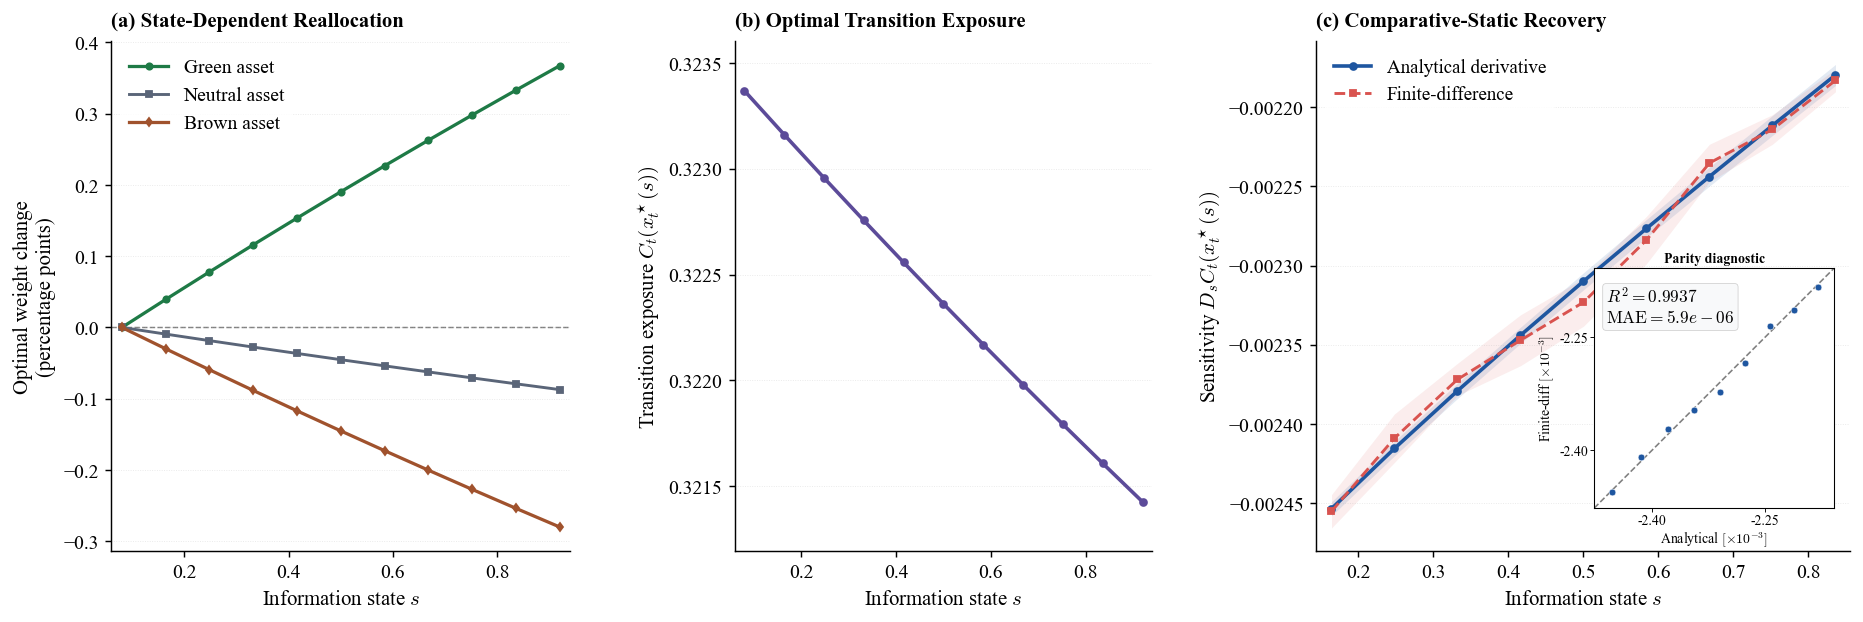

In [3]:
# -------------------------------------------------------------------------
# Figure 2
# -------------------------------------------------------------------------


data_fig2 = pd.read_csv(r"C:\Users\fredy\Downloads\Results_Section4_V5_Full\figure_csv\figure_2_data.csv")

d = data_fig2.sort_values("state").reset_index(drop=True)
s = d["state"].to_numpy()

# Colors
C_GREEN   = "#1E7A46"
C_NEUTRAL = "#5A6578"
C_BROWN   = "#A0522D"
C_EXPOS   = "#5C4B99"
C_ANALYT = "#1E56A0"
C_FD      = "#D9534F"

# Reallocation Calculations
green_change = 100 * (d["w_green_mean"].to_numpy() - d["w_green_mean"].iloc[0])
neutral_change = 100 * (d["w_neutral_mean"].to_numpy() - d["w_neutral_mean"].iloc[0])
brown_change = 100 * (d["w_brown_mean"].to_numpy() - d["w_brown_mean"].iloc[0])

green_low = 100 * (d["w_green_ci_low"].to_numpy() - d["w_green_mean"].iloc[0])
green_high = 100 * (d["w_green_ci_high"].to_numpy() - d["w_green_mean"].iloc[0])

neutral_low = 100 * (d["w_neutral_ci_low"].to_numpy() - d["w_neutral_mean"].iloc[0])
neutral_high = 100 * (d["w_neutral_ci_high"].to_numpy() - d["w_neutral_mean"].iloc[0])

brown_low = 100 * (d["w_brown_ci_low"].to_numpy() - d["w_brown_mean"].iloc[0])
brown_high = 100 * (d["w_brown_ci_high"].to_numpy() - d["w_brown_mean"].iloc[0])

# Exposure
exposure = d["exposure_mean"].to_numpy()
exposure_low = d["exposure_ci_low"].to_numpy()
exposure_high = d["exposure_ci_high"].to_numpy()

# Derivatives
mask = np.isfinite(d["dc_analytical_mean"].to_numpy()) & np.isfinite(d["dc_fd_mean"].to_numpy())
s_deriv = s[mask]

dc_a = d.loc[mask, "dc_analytical_mean"].to_numpy()
dc_a_low = d.loc[mask, "dc_analytical_ci_low"].to_numpy()
dc_a_high = d.loc[mask, "dc_analytical_ci_high"].to_numpy()

dc_fd = d.loc[mask, "dc_fd_mean"].to_numpy()
dc_fd_low = d.loc[mask, "dc_fd_ci_low"].to_numpy()
dc_fd_high = d.loc[mask, "dc_fd_ci_high"].to_numpy()

mae = np.mean(np.abs(dc_fd - dc_a))
ss_res = np.sum((dc_fd - dc_a) ** 2)
ss_tot = np.sum((dc_fd - np.mean(dc_fd)) ** 2)
r2 = 1.0 - ss_res / ss_tot

# -------------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.titlesize": 11.5,
    "axes.labelsize": 11.5,
    "xtick.labelsize": 10.8,
    "ytick.labelsize": 10.8,
    "legend.fontsize": 10.8,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "grid.alpha": 0.3,
    "figure.dpi": 130,
})


fig = plt.figure(figsize=(14.7, 5.3),)

gs = fig.add_gridspec(
    1, 3,
    width_ratios=[1.1, 1.0, 1.28],
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# -------------------------------------------------------------------------
# PANEL (a): STATE-DEPENDENT REALLOCATION
# -------------------------------------------------------------------------
ax1.axhline(0, color="0.5", lw=0.8, ls="--", zorder=0)

ax1.fill_between(s, green_low, green_high, color=C_GREEN, alpha=0.12, lw=0)
ax1.fill_between(s, neutral_low, neutral_high, color=C_NEUTRAL, alpha=0.10, lw=0)
ax1.fill_between(s, brown_low, brown_high, color=C_BROWN, alpha=0.12, lw=0)

ax1.plot(s, green_change, color=C_GREEN, lw=1.8, marker="o", ms=3.5, label="Green asset")
ax1.plot(s, neutral_change, color=C_NEUTRAL, lw=1.6, marker="s", ms=3.2, label="Neutral asset")
ax1.plot(s, brown_change, color=C_BROWN, lw=1.8, marker="d", ms=3.5, label="Brown asset")

ax1.set_title("(a) State-Dependent Reallocation", loc="left", pad=8, fontweight="bold")
ax1.set_xlabel(r"Information state $s$")
ax1.set_ylabel("Optimal weight change\n(percentage points)")
ax1.set_xlim(s.min() - 0.02, s.max() + 0.02)

ax1.legend(frameon=True, facecolor="white", edgecolor="none", framealpha=0.85, loc="upper left", fontsize=10.8)

# -------------------------------------------------------------------------
# PANEL (b): OPTIMAL TRANSITION EXPOSURE
# -------------------------------------------------------------------------
ax2.fill_between(s, exposure_low, exposure_high, color=C_EXPOS, alpha=0.12, lw=0)
ax2.plot(s, exposure, color=C_EXPOS, lw=2.0, marker="o", ms=3.8)

ax2.set_title("(b) Optimal Transition Exposure", loc="left", pad=8, fontweight="bold")
ax2.set_xlabel(r"Information state $s$")
ax2.set_ylabel(r"Transition exposure $C_t(x_t^\star(s))$")
ax2.set_xlim(s.min() - 0.02, s.max() + 0.02)

exp_range = exposure.max() - exposure.min()
ax2.set_ylim(exposure.min() - 0.12 * exp_range, exposure.max() + 0.12 * exp_range)

# -------------------------------------------------------------------------
# PANEL (c): COMPARATIVE-STATIC RECOVERY
# -------------------------------------------------------------------------
ax3.fill_between(s_deriv, dc_a_low, dc_a_high, color=C_ANALYT, alpha=0.12, lw=0)
ax3.fill_between(s_deriv, dc_fd_low, dc_fd_high, color=C_FD, alpha=0.10, lw=0)

ax3.plot(s_deriv, dc_a, color=C_ANALYT, lw=2.0, marker="o", ms=3.8, label="Analytical derivative", zorder=3)
ax3.plot(s_deriv, dc_fd, color=C_FD, lw=1.6, ls="--", marker="s", ms=3.4, label="Finite-difference", zorder=4)

ax3.set_title("(c) Comparative-Static Recovery", loc="left", pad=8, fontweight="bold")
ax3.set_xlabel(r"Information state $s$")
ax3.set_ylabel(r"Sensitivity $D_s C_t(x_t^\star(s))$")
ax3.set_xlim(s_deriv.min() - 0.02, s_deriv.max() + 0.02)

ax3.legend(frameon=True, facecolor="white", edgecolor="none", framealpha=0.85, loc="upper left", fontsize=10.5)

# -------------------------------------------------------------------------

axins = ax3.inset_axes([0.52, 0.08, 0.45, 0.48])

lower = min(dc_a.min(), dc_fd.min())
upper = max(dc_a.max(), dc_fd.max())
p_pad = 0.08 * (upper - lower)
lims = [lower - p_pad, upper + p_pad]

scale = 1e3
lims_scaled = [l * scale for l in lims]

axins.plot(lims_scaled, lims_scaled, color="0.5", lw=0.9, ls="--", zorder=1)
axins.scatter(dc_a * scale, dc_fd * scale, s=14, color=C_ANALYT, edgecolor="white", linewidth=0.3, zorder=3)

axins.set_xlim(lims_scaled)
axins.set_ylim(lims_scaled)
axins.set_aspect("equal", adjustable="box")

axins.xaxis.set_major_locator(MaxNLocator(nbins=3))
axins.yaxis.set_major_locator(MaxNLocator(nbins=3))
axins.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axins.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

axins.set_xlabel(r"Analytical $[\times 10^{-3}]$", fontsize=7.7, labelpad=1.5)
axins.set_ylabel(r"Finite-diff $[\times 10^{-3}]$", fontsize=7.7, labelpad=1.5)
axins.set_title("Parity diagnostic", fontsize=7.7, pad=3, fontweight="bold")
axins.tick_params(axis="both", labelsize=7.7, length=2, width=0.5, pad=1)

axins.text(
    0.05, 0.92,
    rf"$R^2={r2:.4f}$" "\n" rf"$\mathrm{{MAE}}={mae:.1e}$",
    transform=axins.transAxes, ha="left", va="top",
    fontsize=9.6,
    bbox=dict(boxstyle="round,pad=0.2", facecolor="#F8F9FA", edgecolor="0.8", lw=0.4)
)

for spine in axins.spines.values():
    spine.set_linewidth(0.6)

for ax in (ax1, ax2, ax3):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3.5, width=0.8)
    ax.grid(True, axis="y", ls=":", color="0.7")

fig.align_ylabels([ax1, ax2, ax3])

plt.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.14, wspace=0.36)
plt.show()

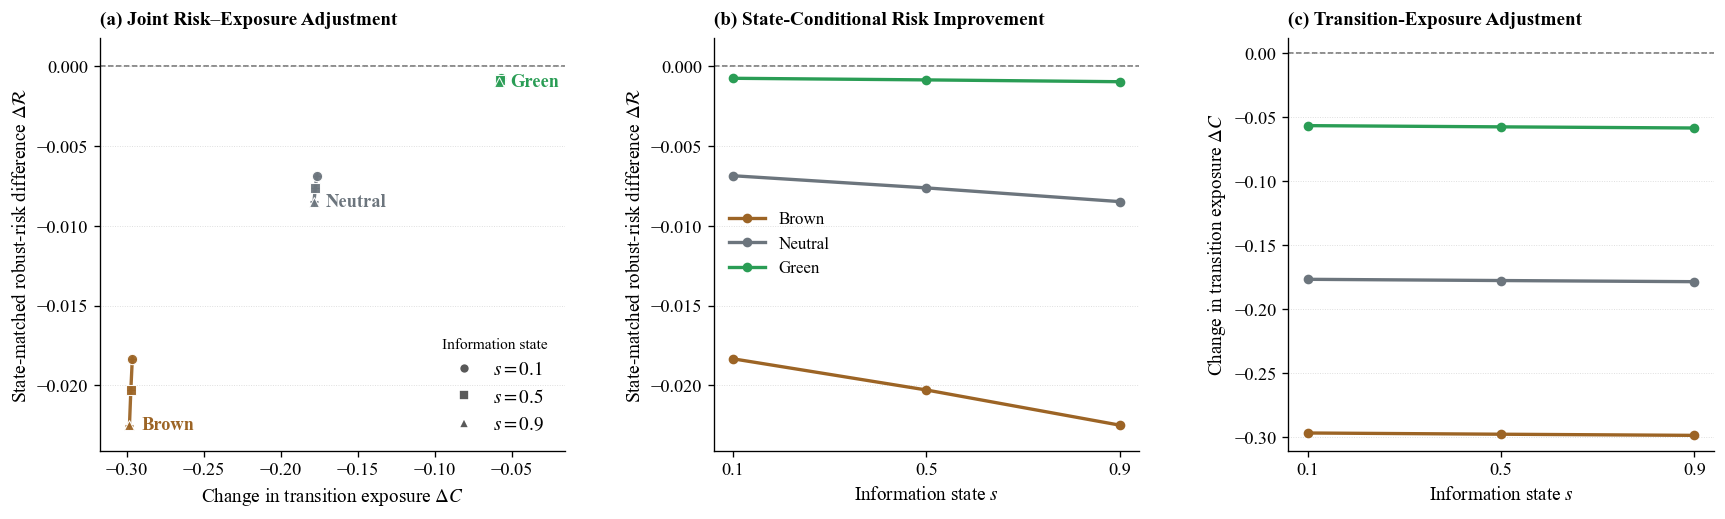

In [4]:
# -------------------------------------------------------------------------
# Figure 3
# -------------------------------------------------------------------------


data_fig3 = pd.read_csv(
    r"C:\Users\fredy\Downloads\Results_Section4_V5_Full"
    r"\figure_csv\figure_3_data_state_matched.csv"
)

d = data_fig3.copy()


# ---------------------------------------------------------------------------
# Portfolio ordering
# ---------------------------------------------------------------------------

d["portfolio"] = pd.Categorical(
    d["portfolio"],
    categories=["Brown", "Neutral", "Green"],
    ordered=True
)

d = (d.sort_values(["portfolio", "state"]).reset_index(drop=True))

required_columns = [
    "portfolio",
    "state",
    "delta_risk_mean",
    "delta_risk_ci_low",
    "delta_risk_ci_high",

    "delta_c_mean",
    "delta_c_ci_low",
    "delta_c_ci_high",
]

missing = [
    col
    for col in required_columns
    if col not in d.columns
]

max_delta_risk = float(
    d["delta_risk_mean"].max()
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10.5,

    "axes.titlesize": 11.5,
    "axes.labelsize": 11.5,

    "xtick.labelsize": 11.0,
    "ytick.labelsize": 11.0,

    "legend.fontsize": 10.2,

    "axes.linewidth": 0.8,

    "mathtext.fontset": "stix",

    "figure.dpi": 120,
})


# ---------------------------------------------------------------------------
# Muted publication palette
# ---------------------------------------------------------------------------

C_BROWN = "#9C6425"
C_NEUTRAL = "#6C757D"
C_GREEN = "#2A9D55"

COLORS = {
    "Brown": C_BROWN,
    "Neutral": C_NEUTRAL,
    "Green": C_GREEN,
}


# ---------------------------------------------------------------------------
# State-specific markers
# ---------------------------------------------------------------------------

MARKERS = {
    0.1: "o",
    0.5: "s",
    0.9: "^",
}


# FIGURE

fig = plt.figure(
    figsize=(14.7, 4.65)
)

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.18, 1.08, 1.08],
    wspace=0.34,
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])


# ============================================================================
# PANEL (a)
# JOINT STATE-MATCHED RISK–EXPOSURE ADJUSTMENT
# ============================================================================

# Zero-risk-difference benchmark
ax1.axhline(
    0.0,
    color="0.42",
    lw=0.90,
    ls="--",
    zorder=0,
)


for portfolio in ["Brown", "Neutral", "Green"]:

    z = (d[d["portfolio"] == portfolio].sort_values("state").copy())

    color = COLORS[portfolio]

    ax1.plot(
        z["delta_c_mean"],
        z["delta_risk_mean"],
        color=color,
        lw=2.0,
        alpha=0.95,
        zorder=2,
    )

    # State-specific markers + 95% CIs
    for _, row in z.iterrows():
        state = float(row["state"])
        # Robust marker lookup against floating-point representation
        state_key = min(MARKERS.keys(), key=lambda x: abs(x - state))

        xerr = np.array([
            [row["delta_c_mean"] - row["delta_c_ci_low"]],
            [row["delta_c_ci_high"] - row["delta_c_mean"]],
        ])

        yerr = np.array([
            [row["delta_risk_mean"] - row["delta_risk_ci_low"]],
            [row["delta_risk_ci_high"] - row["delta_risk_mean"]],
        ])

        ax1.errorbar(
            row["delta_c_mean"],
            row["delta_risk_mean"],
            xerr=xerr,
            yerr=yerr,
            fmt=MARKERS[state_key],
            ms=6.2,
            mfc=color,
            mec="white",
            mew=0.65,
            ecolor=color,
            elinewidth=0.85,
            capsize=2.2,
            alpha=0.95,
            zorder=4,
        )

    last = z.iloc[-1]

    ax1.annotate(
        portfolio,
        xy=(
            last["delta_c_mean"],
            last["delta_risk_mean"],
        ),
        xytext=(7, 0),
        textcoords="offset points",
        color=color,
        fontsize=11.1,
        fontweight="bold",
        va="center",
    )


ax1.set_title(
    "(a) Joint Risk–Exposure Adjustment",
    loc="left",
    pad=8,
    fontweight="bold",
)

ax1.set_xlabel(r"Change in transition exposure $\Delta C$")

ax1.set_ylabel(r"State-matched robust-risk difference $\Delta\mathcal{R}$")


# ---------------------------------------------------------------------------
# Panel (a) limits
# ---------------------------------------------------------------------------

x_min = float(d["delta_c_ci_low"].min())

x_max = float(d["delta_c_ci_high"].max())

x_range = max(x_max - x_min, 1e-8)

ax1.set_xlim(
    x_min - 0.08 * x_range,
    x_max + 0.17 * x_range,
)


y_min_a = float(d["delta_risk_ci_low"].min())

y_max_a = max(0.0, float(d["delta_risk_ci_high"].max()))

y_range_a = max(y_max_a - y_min_a, 1e-8)

ax1.set_ylim(
    y_min_a - 0.07 * y_range_a,
    y_max_a + 0.08 * y_range_a,
)


# ============================================================================
# PANEL (b)
# STATE-CONDITIONAL RISK IMPROVEMENT
# ============================================================================

ax2.axhline(
    0.0,
    color="0.42",
    lw=0.90,
    ls="--",
    zorder=0,
)


for portfolio in ["Brown", "Neutral", "Green"]:

    z = (d[d["portfolio"] == portfolio].sort_values("state").copy())

    color = COLORS[portfolio]

    ax2.fill_between(
        z["state"].to_numpy(dtype=float),
        z["delta_risk_ci_low"].to_numpy(dtype=float),
        z["delta_risk_ci_high"].to_numpy(dtype=float),
        color=color,
        alpha=0.10,
        linewidth=0,
        zorder=1,
    )

    ax2.plot(
        z["state"],
        z["delta_risk_mean"],
        color=color,
        lw=2.0,
        marker="o",
        ms=4.8,
        label=portfolio,
        zorder=3,
    )


ax2.set_title(
    "(b) State-Conditional Risk Improvement",
    loc="left",
    pad=8,
    fontweight="bold",
)

ax2.set_xlabel(r"Information state $s$")

ax2.set_ylabel(r"State-matched robust-risk difference $\Delta\mathcal{R}$")

ax2.set_xlim(0.06, 0.94)

ax2.set_xticks([0.1, 0.5, 0.9])


y_min_b = float(d["delta_risk_ci_low"].min())

y_max_b = max(0.0, float(d["delta_risk_ci_high"].max()))

y_range_b = max(y_max_b - y_min_b, 1e-8,)

ax2.set_ylim(
    y_min_b - 0.07 * y_range_b,
    y_max_b + 0.08 * y_range_b,
)


# ============================================================================
# PANEL (c)
# TRANSITION-EXPOSURE ADJUSTMENT
# ============================================================================

ax3.axhline(0.0, color="0.42", lw=0.90, ls="--", zorder=0,)


for portfolio in ["Brown", "Neutral", "Green"]:

    z = (d[d["portfolio"] == portfolio].sort_values("state").copy())

    color = COLORS[portfolio]

    ax3.fill_between(
        z["state"].to_numpy(dtype=float),
        z["delta_c_ci_low"].to_numpy(dtype=float),
        z["delta_c_ci_high"].to_numpy(dtype=float),
        color=color,
        alpha=0.10,
        linewidth=0,
        zorder=1,
    )

    ax3.plot(
        z["state"],
        z["delta_c_mean"],
        color=color,
        lw=2.0,
        marker="o",
        ms=4.8,
        label=portfolio,
        zorder=3,
    )


ax3.set_title(
    "(c) Transition-Exposure Adjustment",
    loc="left",
    pad=8,
    fontweight="bold",
)

ax3.set_xlabel(r"Information state $s$")

ax3.set_ylabel(r"Change in transition exposure $\Delta C$")

ax3.set_xlim(0.06, 0.94,)

ax3.set_xticks([0.1, 0.5, 0.9])


c_min = float(d["delta_c_ci_low"].min())

c_max = max(0.0, float(d["delta_c_ci_high"].max()))

c_range = max(c_max - c_min, 1e-8,)

ax3.set_ylim(
    c_min - 0.04 * c_range,
    c_max + 0.04 * c_range,
)



portfolio_handles = [

    Line2D(
        [0], [0],
        color=C_BROWN,
        lw=2.0,
        marker="o",
        ms=4.8,
        label="Brown",
    ),

    Line2D(
        [0], [0],
        color=C_NEUTRAL,
        lw=2.0,
        marker="o",
        ms=4.8,
        label="Neutral",
    ),

    Line2D(
        [0], [0],
        color=C_GREEN,
        lw=2.0,
        marker="o",
        ms=4.8,
        label="Green",
    ),
]


state_handles = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color="none",
        markerfacecolor="0.35",
        markeredgecolor="white",
        markersize=6,
        label=r"$s=0.1$",
    ),

    Line2D(
        [0], [0],
        marker="s",
        linestyle="None",
        color="none",
        markerfacecolor="0.35",
        markeredgecolor="white",
        markersize=6,
        label=r"$s=0.5$",
    ),

    Line2D(
        [0], [0],
        marker="^",
        linestyle="None",
        color="none",
        markerfacecolor="0.35",
        markeredgecolor="white",
        markersize=6,
        label=r"$s=0.9$",
    ),
]

ax2.legend(
    handles=portfolio_handles,
    frameon=False,
    loc="center left",
    handlelength=2.1,
)

ax1.legend(
    handles=state_handles,
    title="Information state",
    frameon=False,
    loc="lower right",
    fontsize=11.4,
    title_fontsize=9.2,
    handletextpad=0.5,
)

for ax in (ax1, ax2, ax3,):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)


    ax.tick_params(
        direction="out",
        length=3.5,
        width=0.8,
    )

    ax.grid(
        True,
        axis="y",

        linestyle=":",
        linewidth=0.55,

        color="0.72",
        alpha=0.50,

        zorder=0,
    )

plt.subplots_adjust(
    left=0.070,
    right=0.985,
    top=0.90,
    bottom=0.16,
    wspace=0.34,
)

plt.show()


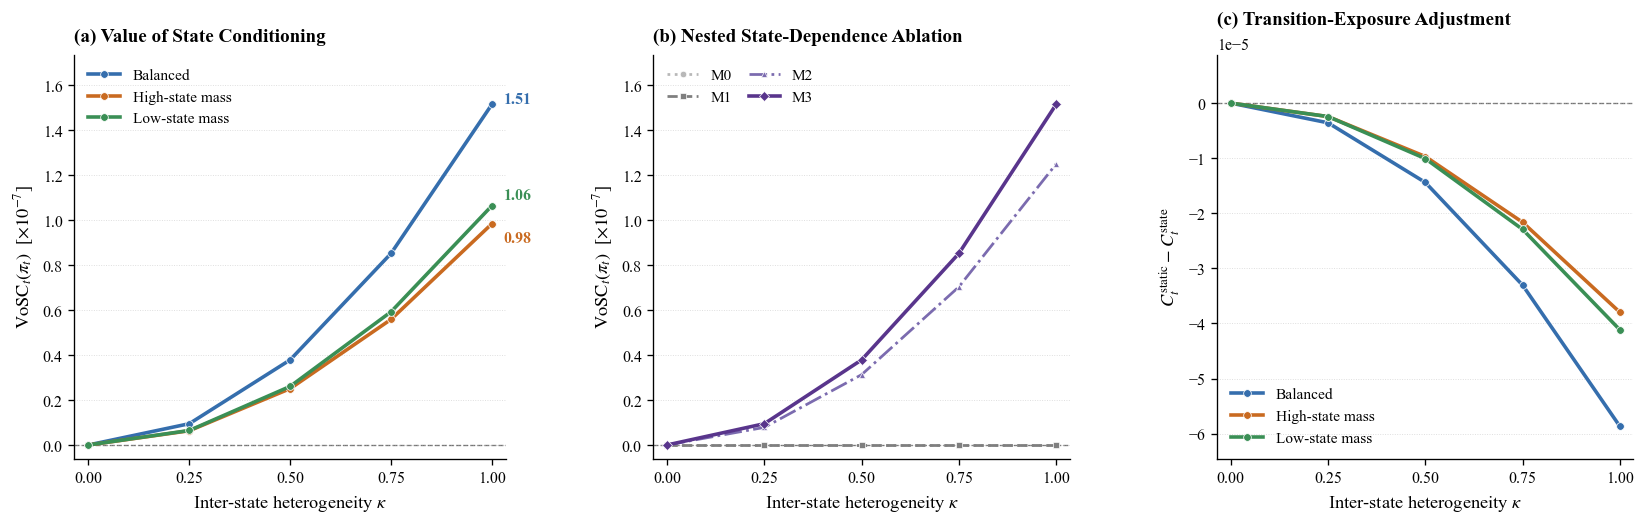

In [5]:
# -------------------------------------------------------------------------
# Figure 4
# -------------------------------------------------------------------------


data_fig4 = pd.read_csv(r"C:\Users\fredy\Downloads\Results_Section4_V5_Full\figure_csv\figure_4_data.csv")

d = data_fig4.copy()


required = [
    "model",
    "pi",
    "kappa",
    "v_state_mean",
    "v_static_mean",
    "vosc_mean",
    "vosc_ci_low",
    "vosc_ci_high",
    "c_state_mean",
    "c_static_mean",
    "n_seed"
]

missing = [col for col in required if col not in d.columns]

expected_kappa = np.array([0.00, 0.25, 0.50, 0.75, 1.00])

observed_kappa = np.sort(d["kappa"].dropna().unique())


vosc_identity_error = np.max(
    np.abs(
        (d["v_static_mean"] - d["v_state_mean"])
        - d["vosc_mean"]
    )
)

VOSC_SCALE = 1e7

d["vosc_plot"] = (VOSC_SCALE * d["vosc_mean"])

d["vosc_low_plot"] = (VOSC_SCALE * d["vosc_ci_low"])

d["vosc_high_plot"] = (VOSC_SCALE * d["vosc_ci_high"])


# Transition-exposure adjustment:

d["exposure_gap"] = (d["c_static_mean"] - d["c_state_mean"])

full = (d[d["model"] == "M3"].copy())

# Evaluation-distribution colors

C_BALANCED = "#356EAD"
C_HIGH = "#C96A20"
C_LOW = "#3A8F55"

PI_COLORS = {
    "balanced": C_BALANCED,
    "high": C_HIGH,
    "low": C_LOW
}

PI_LABELS = {
    "balanced": "Balanced",
    "high": "High-state mass",
    "low": "Low-state mass"
}


# Nested-model colors

C_M0 = "#B8B8B8"
C_M1 = "#7F7F7F"
C_M2 = "#7B6BAF"
C_M3 = "#59358C"

MODEL_COLORS = {
    "M0": C_M0,
    "M1": C_M1,
    "M2": C_M2,
    "M3": C_M3
}


# Distinct line styles help preserve readability in grayscale

MODEL_STYLES = {
    "M0": ":",
    "M1": "--",
    "M2": "-.",
    "M3": "-"
}

MODEL_MARKERS = {
    "M0": "o",
    "M1": "s",
    "M2": "^",
    "M3": "D"
}


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11.5,
    "axes.titlesize": 11.5,
    "axes.labelsize": 11.0,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.2,
    "axes.linewidth": 0.8,
    "mathtext.fontset": "stix",
    "figure.dpi": 120,
})



fig = plt.figure(figsize=(14.2, 4.55))

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.12, 1.08, 1.08],
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0, 0])

ax2 = fig.add_subplot(gs[0, 1])

ax3 = fig.add_subplot(gs[0, 2])


# =============================================================================
# PANEL (a)
# =============================================================================

ax1.axhline(
    0,
    color="0.45",
    lw=0.8,
    ls="--",
    zorder=0
)


for pi_name in ["balanced", "high", "low"]:

    z = (full[full["pi"] == pi_name].sort_values("kappa").copy())

    color = PI_COLORS[pi_name]

    ax1.fill_between(
        z["kappa"].to_numpy(),
        z["vosc_low_plot"].to_numpy(),
        z["vosc_high_plot"].to_numpy(),
        color=color,
        alpha=0.11,
        linewidth=0,
        zorder=1
    )

    ax1.plot(
        z["kappa"],
        z["vosc_plot"],
        color=color,
        lw=2.15,
        marker="o",
        ms=4.6,
        markeredgecolor="white",
        markeredgewidth=0.45,
        label=PI_LABELS[pi_name],
        zorder=3
    )


ax1.set_title(
    "(a) Value of State Conditioning",
    loc="left",
    pad=8,
    fontweight="bold"
)

ax1.set_xlabel(r"Inter-state heterogeneity $\kappa$")

ax1.set_ylabel(r"$\mathrm{VoSC}_t(\pi_t)$  [$\times 10^{-7}$]")

ax1.set_xlim(-0.035, 1.035)

ax1.set_xticks([0.00, 0.25, 0.50, 0.75, 1.00])

ax1.legend(
    frameon=False,
    loc="upper left",
    handlelength=2.1
)

annotation_offsets = {
    "balanced": (7, 3),
    "high": (7, -9),
    "low": (7, 6)
}


for pi_name in ["balanced", "high", "low"]:
    z = (full[full["pi"] == pi_name].sort_values("kappa").copy())

    last = z.iloc[-1]

    ax1.annotate(
        f'{last["vosc_plot"]:.2f}',
        xy=(last["kappa"], last["vosc_plot"]),
        xytext=annotation_offsets[pi_name],
        textcoords="offset points",
        color=PI_COLORS[pi_name],
        fontsize=9.5,
        fontweight="bold",
        ha="left",
        va="center"
    )


# =============================================================================
# PANEL (b)
# =============================================================================

abl = (d[d["pi"] == "balanced"].copy())


ax2.axhline(
    0,
    color="0.45",
    lw=0.8,
    ls="--",
    zorder=0
)


for model in ["M0", "M1", "M2", "M3"]:

    z = (abl[abl["model"] == model].sort_values("kappa").copy())

    color = MODEL_COLORS[model]

    interval_width = (z["vosc_high_plot"].to_numpy() - z["vosc_low_plot"].to_numpy())

    if np.max(np.abs(interval_width)) > 1e-14:

        ax2.fill_between(
            z["kappa"].to_numpy(),
            z["vosc_low_plot"].to_numpy(),
            z["vosc_high_plot"].to_numpy(),
            color=color,
            alpha=0.075,
            linewidth=0,
            zorder=1
        )

    ax2.plot(
        z["kappa"],
        z["vosc_plot"],
        color=color,
        lw=2.15 if model == "M3" else 1.65,
        ls=MODEL_STYLES[model],
        marker=MODEL_MARKERS[model],
        ms=4.4 if model == "M3" else 3.9,
        markeredgecolor="white",
        markeredgewidth=0.40,
        label=model,
        zorder=3
    )

ax2.set_title(
    "(b) Nested State-Dependence Ablation",
    loc="left",
    pad=8,
    fontweight="bold"
)

ax2.set_xlabel(r"Inter-state heterogeneity $\kappa$")

ax2.set_ylabel(r"$\mathrm{VoSC}_t(\pi_t)$  [$\times 10^{-7}$]")

ax2.set_xlim(-0.035, 1.035)

ax2.set_xticks([0.00, 0.25, 0.50, 0.75, 1.00])

ax2.legend(
    frameon=False,
    loc="upper left",
    ncol=2,
    columnspacing=1.15,
    handlelength=2.0
)


# =============================================================================
# PANEL (c)
# =============================================================================

ax3.axhline(
    0,
    color="0.45",
    lw=0.8,
    ls="--",
    zorder=0
)

for pi_name in ["balanced", "high", "low"]:
    z = (full[full["pi"] == pi_name].sort_values("kappa").copy())

    color = PI_COLORS[pi_name]

    ax3.plot(
        z["kappa"],
        z["exposure_gap"],
        color=color,
        lw=2.15,
        marker="o",
        ms=4.6,
        markeredgecolor="white",
        markeredgewidth=0.45,
        label=PI_LABELS[pi_name],
        zorder=3
    )


ax3.set_title(
    "(c) Transition-Exposure Adjustment",
    loc="left",
    pad=8,
    fontweight="bold"
)

ax3.set_xlabel(r"Inter-state heterogeneity $\kappa$")

ax3.set_ylabel(r"$C_t^{\mathrm{static}}-C_t^{\mathrm{state}}$")

ax3.set_xlim(-0.035, 1.035)

ax3.set_xticks([0.00, 0.25, 0.50, 0.75, 1.00])

ax3.legend(
    frameon=False,
    loc="best",
    handlelength=2.1
)


all_vosc_upper = max(d["vosc_high_plot"].max(), d["vosc_plot"].max())

all_vosc_lower = min(0, d["vosc_low_plot"].min())

vosc_range = (all_vosc_upper - all_vosc_lower)

if vosc_range <= 0:
    vosc_range = 1.0

ax1.set_ylim(
    all_vosc_lower - 0.04 * vosc_range,
    all_vosc_upper + 0.14 * vosc_range
)

ax2.set_ylim(
    all_vosc_lower - 0.04 * vosc_range,
    all_vosc_upper + 0.14 * vosc_range
)


gap_min = (full["exposure_gap"].min())

gap_max = (full["exposure_gap"].max())

gap_range = (gap_max - gap_min)

if gap_range <= 0:
    gap_range = max(abs(gap_max), 1e-6)

ax3.set_ylim(
    min(0, gap_min - 0.10 * gap_range),
    gap_max + 0.15 * gap_range
)


for ax in (ax1, ax2, ax3):

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)

    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        direction="out",
        length=3.5,
        width=0.8
    )

    ax.grid(
        True,
        axis="y",
        linestyle=":",
        linewidth=0.55,
        color="0.72",
        alpha=0.50
    )

fig.align_ylabels([ax1, ax2, ax3])

plt.subplots_adjust(
    left=0.070,
    right=0.985,
    top=0.90,
    bottom=0.16,
    wspace=0.35
)


plt.show()


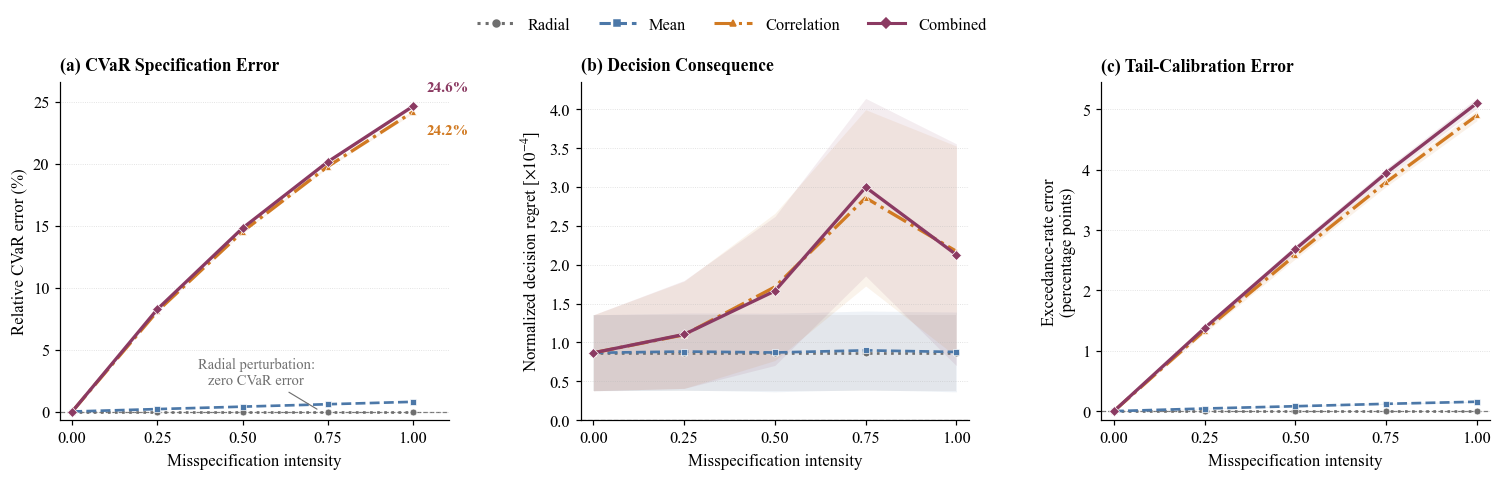

In [6]:
# -------------------------------------------------------------------------
# Figure 5
# -------------------------------------------------------------------------


data_fig5 = pd.read_csv(r"C:\Users\fredy\Downloads\Results_Section4_V5_Full\figure_csv\figure_5_data.csv")

d = data_fig5.copy()

required = [
    "dgp",
    "intensity",
    "cvar_rel_error_mean",
    "cvar_rel_error_ci_low",
    "cvar_rel_error_ci_high",
    "normalized_regret_mean",
    "normalized_regret_ci_low",
    "normalized_regret_ci_high",
    "tail_exceedance_mean",
    "tail_exceedance_ci_low",
    "tail_exceedance_ci_high",
    "exceedance_error_mean",
    "exceedance_error_ci_low",
    "exceedance_error_ci_high",
    "delta_c_mean",
    "delta_c_ci_low",
    "delta_c_ci_high",
    "n_seed"
]

missing = [col for col in required if col not in d.columns]


dgp_order = ["radial", "mean", "correlation", "combined"]

d["dgp"] = pd.Categorical(d["dgp"], categories=dgp_order, ordered=True)

d = (d.sort_values(["dgp", "intensity"]).reset_index(drop=True))

# Relative CVaR error as percentage
d["cvar_pct"] = (100.0 * d["cvar_rel_error_mean"])

d["cvar_pct_low"] = (100.0 * d["cvar_rel_error_ci_low"])

d["cvar_pct_high"] = (100.0 * d["cvar_rel_error_ci_high"])

REGRET_SCALE = 1e4

d["regret_plot"] = (REGRET_SCALE * d["normalized_regret_mean"])

d["regret_low_plot"] = (REGRET_SCALE * d["normalized_regret_ci_low"])

d["regret_high_plot"] = (REGRET_SCALE * d["normalized_regret_ci_high"])

# Tail exceedance error in percentage points
d["tail_error_pp"] = (100.0 * d["exceedance_error_mean"])

d["tail_error_pp_low"] = (100.0 * d["exceedance_error_ci_low"])

d["tail_error_pp_high"] = (100.0 * d["exceedance_error_ci_high"])


C_RADIAL = "#6F6F6F"
C_MEAN = "#4C78A8"
C_CORR = "#D17A22"
C_COMBINED = "#8B3A62"

DGP_COLORS = {
    "radial": C_RADIAL,
    "mean": C_MEAN,
    "correlation": C_CORR,
    "combined": C_COMBINED
}

DGP_LABELS = {
    "radial": "Radial",
    "mean": "Mean",
    "correlation": "Correlation",
    "combined": "Combined"
}

DGP_MARKERS = {
    "radial": "o",
    "mean": "s",
    "correlation": "^",
    "combined": "D"
}

DGP_STYLES = {
    "radial": ":",
    "mean": "--",
    "correlation": "-.",
    "combined": "-"
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11.5,
    "axes.titlesize": 11.5,
    "axes.labelsize": 11.0,
    "xtick.labelsize": 10.7,
    "ytick.labelsize": 10.7,
    "legend.fontsize": 10.7,
    "axes.linewidth": 0.8,
    "mathtext.fontset": "stix",
    "figure.dpi": 110,
})


# FIGURE

fig = plt.figure(figsize=(14.2, 4.55))

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.06, 1.06, 1.06],
    wspace=0.34
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])


# =============================================================================
# PANEL (a)
# RELATIVE CVaR SPECIFICATION ERROR
# =============================================================================

ax1.axhline(
    0,
    color="0.45",
    lw=0.8,
    ls="--",
    zorder=0
)

for dgp_name in dgp_order:

    z = (d[d["dgp"] == dgp_name].sort_values("intensity").copy())

    color = DGP_COLORS[dgp_name]

    ax1.fill_between(
        z["intensity"].to_numpy(),
        z["cvar_pct_low"].to_numpy(),
        z["cvar_pct_high"].to_numpy(),
        color=color,
        alpha=0.10,
        linewidth=0,
        zorder=1
    )

    ax1.plot(
        z["intensity"],
        z["cvar_pct"],
        color=color,
        lw=2.15 if dgp_name in ["correlation", "combined"] else 1.75,
        ls=DGP_STYLES[dgp_name],
        marker=DGP_MARKERS[dgp_name],
        ms=4.5,
        markeredgecolor="white",
        markeredgewidth=0.45,
        label=DGP_LABELS[dgp_name],
        zorder=3
    )


ax1.set_title(
    "(a) CVaR Specification Error",
    loc="left",
    pad=8,
    fontweight="bold"
)

ax1.set_xlabel("Misspecification intensity")
ax1.set_ylabel("Relative CVaR error (%)")

# Extra room on the right for direct endpoint labels
ax1.set_xlim(-0.035, 1.105)

ax1.set_xticks([0.00, 0.25, 0.50, 0.75, 1.00])


cvar_upper = d["cvar_pct_high"].max()

ax1.set_ylim(bottom=-0.7, top=cvar_upper + 1.8)


# =============================================================================
# RADIAL INVARIANCE ANNOTATION — PANEL (a)
# =============================================================================

radial_max = (d[d["dgp"] == "radial"]["cvar_pct"].abs().max())

if radial_max < 1e-10:

    ax1.annotate(
        "Radial perturbation:\nzero CVaR error",
        xy=(0.73, 0.0),
        xytext=(0.54, 3.15),
        textcoords="data",
        fontsize=9.6,
        color=C_RADIAL,
        ha="center",
        va="center",
        arrowprops=dict(
            arrowstyle="-",
            color=C_RADIAL,
            lw=0.75,
            shrinkA=2,
            shrinkB=3
        )
    )


# =============================================================================
# DIRECT ENDPOINT LABELS — PANEL (a)
# =============================================================================

z_combined = (d[d["dgp"] == "combined"].sort_values("intensity").copy())

z_correlation = (d[d["dgp"] == "correlation"].sort_values("intensity").copy())

last_combined = z_combined.iloc[-1]
last_correlation = z_correlation.iloc[-1]


# Combined — above/right
ax1.annotate(
    f'{last_combined["cvar_pct"]:.1f}%',
    xy=(
        last_combined["intensity"],
        last_combined["cvar_pct"]
    ),
    xytext=(9, 8),
    textcoords="offset points",
    color=DGP_COLORS["combined"],
    fontsize=10.1,
    fontweight="bold",
    ha="left",
    va="bottom",
    annotation_clip=False
)


# Correlation — below/right
ax1.annotate(
    f'{last_correlation["cvar_pct"]:.1f}%',
    xy=(
        last_correlation["intensity"],
        last_correlation["cvar_pct"]
    ),
    xytext=(9, -8),
    textcoords="offset points",
    color=DGP_COLORS["correlation"],
    fontsize=10.1,
    fontweight="bold",
    ha="left",
    va="top",
    annotation_clip=False
)


# =============================================================================
# PANEL (b)
# NORMALIZED DECISION REGRET
# =============================================================================

ax2.axhline(
    0,
    color="0.45",
    lw=0.8,
    ls="--",
    zorder=0
)

for dgp_name in dgp_order:

    z = (d[d["dgp"] == dgp_name].sort_values("intensity").copy())

    color = DGP_COLORS[dgp_name]

    ax2.fill_between(
        z["intensity"].to_numpy(),
        z["regret_low_plot"].to_numpy(),
        z["regret_high_plot"].to_numpy(),
        color=color,
        alpha=0.09,
        linewidth=0,
        zorder=1
    )

    ax2.plot(
        z["intensity"],
        z["regret_plot"],
        color=color,
        lw=2.15 if dgp_name in ["correlation", "combined"] else 1.75,
        ls=DGP_STYLES[dgp_name],
        marker=DGP_MARKERS[dgp_name],
        ms=4.5,
        markeredgecolor="white",
        markeredgewidth=0.45,
        label=DGP_LABELS[dgp_name],
        zorder=3
    )


ax2.set_title(
    "(b) Decision Consequence",
    loc="left",
    pad=8,
    fontweight="bold"
)

ax2.set_xlabel("Misspecification intensity")

ax2.set_ylabel(
    r"Normalized decision regret [$\times 10^{-4}$]"
)

ax2.set_xlim(-0.035, 1.035)

ax2.set_xticks(
    [0.00, 0.25, 0.50, 0.75, 1.00]
)

ax2.set_ylim(
    bottom=0
)


# =============================================================================
# PANEL (c)
# TAIL CALIBRATION ERROR
# =============================================================================

ax3.axhline(
    0,
    color="0.45",
    lw=0.8,
    ls="--",
    zorder=0
)

for dgp_name in dgp_order:

    z = (d[d["dgp"] == dgp_name].sort_values("intensity").copy())

    color = DGP_COLORS[dgp_name]

    ax3.fill_between(
        z["intensity"].to_numpy(),
        z["tail_error_pp_low"].to_numpy(),
        z["tail_error_pp_high"].to_numpy(),
        color=color,
        alpha=0.10,
        linewidth=0,
        zorder=1
    )

    ax3.plot(
        z["intensity"],
        z["tail_error_pp"],
        color=color,
        lw=2.15 if dgp_name in ["correlation", "combined"] else 1.75,
        ls=DGP_STYLES[dgp_name],
        marker=DGP_MARKERS[dgp_name],
        ms=4.5,
        markeredgecolor="white",
        markeredgewidth=0.45,
        label=DGP_LABELS[dgp_name],
        zorder=3
    )


ax3.set_title(
    "(c) Tail-Calibration Error",
    loc="left",
    pad=8,
    fontweight="bold"
)

ax3.set_xlabel("Misspecification intensity")

ax3.set_ylabel("Exceedance-rate error\n(percentage points)")

ax3.set_xlim(-0.035, 1.035)

ax3.set_xticks([0.00, 0.25, 0.50, 0.75, 1.00])

ax3.set_ylim(bottom=-0.15)


handles = []
labels = []

for dgp_name in dgp_order:

    handle, = ax1.plot(
        [],
        [],
        color=DGP_COLORS[dgp_name],
        lw=2.0,
        ls=DGP_STYLES[dgp_name],
        marker=DGP_MARKERS[dgp_name],
        ms=4.5
    )

    handles.append(handle)
    labels.append(DGP_LABELS[dgp_name])


fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.50, 0.995),
    ncol=4,
    frameon=False,
    columnspacing=1.7,
    handlelength=2.3
)

for ax in (ax1, ax2, ax3):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        direction="out",
        length=3.5,
        width=0.8
    )

    ax.grid(
        True,
        axis="y",
        linestyle=":",
        linewidth=0.55,
        color="0.72",
        alpha=0.50
    )


plt.subplots_adjust(
    left=0.070,
    right=0.985,
    top=0.835,
    bottom=0.16,
    wspace=0.34
)

plt.show()



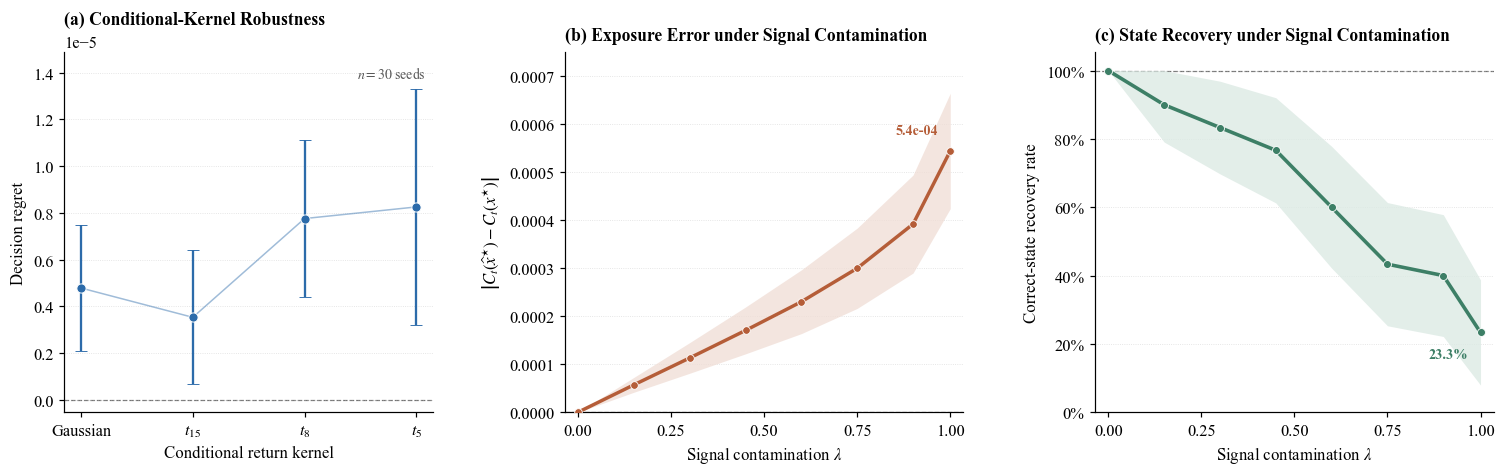

In [7]:
# -------------------------------------------------------------------------
# Figure 6
# -------------------------------------------------------------------------

from matplotlib.ticker import  PercentFormatter

data_fig6 = pd.read_csv(r"C:\Users\fredy\Downloads\Results_Section4_V5_Full\figure_csv\figure_6_data.csv")

d = data_fig6.copy()

kernel = (d[d["panel"] == "kernel"].copy())

cont = (d[d["panel"] == "contamination"].sort_values("lambda").copy())


# =============================================================================
# ORDER CONDITIONAL KERNELS
# Increasing tail thickness
# =============================================================================

kernel_order = ["Gaussian", "t15", "t8", "t5"]

kernel["kernel"] = pd.Categorical(
    kernel["kernel"],
    categories=kernel_order,
    ordered=True)

kernel = (kernel.sort_values("kernel").reset_index(drop=True))


# NUMERICAL ARRAYS

x_kernel = np.arange(len(kernel))

kernel_mean = kernel["decision_regret_mean"].to_numpy()
kernel_low = kernel["decision_regret_ci_low"].to_numpy()
kernel_high = kernel["decision_regret_ci_high"].to_numpy()

kernel_yerr = np.vstack([
    kernel_mean - kernel_low,
    kernel_high - kernel_mean
])

lam = cont["lambda"].to_numpy()

exposure_mean = cont["exposure_abs_error_mean"].to_numpy()
exposure_low = cont["exposure_abs_error_ci_low"].to_numpy()
exposure_high = cont["exposure_abs_error_ci_high"].to_numpy()

state_correct = cont["state_correct_mean"].to_numpy()
state_correct_low = cont["state_correct_ci_low"].to_numpy()
state_correct_high = cont["state_correct_ci_high"].to_numpy()

state_correct_low = np.clip(state_correct_low, 0.0, 1.0)
state_correct_high = np.clip(state_correct_high, 0.0, 1.0)

C_KERNEL = "#2C6BAA"
C_EXPOSURE = "#B55D38"
C_STATE = "#3D7F66"

C_CI_KERNEL = "#D8E6F3"
C_CI_EXPOSURE = "#F0DDD5"
C_CI_STATE = "#DCEAE4"

C_ZERO = "0.45"
C_GRID = "0.75"


# FIGURE

fig = plt.figure(figsize=(14.2, 4.55))

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.00, 1.08, 1.08],
    wspace=0.34
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])


# =============================================================================
# PANEL (a)
# CONDITIONAL-KERNEL ROBUSTNESS
# =============================================================================

ax1.axhline(
    0,
    color=C_ZERO,
    lw=0.8,
    ls="--",
    zorder=0
)

ax1.errorbar(
    x_kernel,
    kernel_mean,
    yerr=kernel_yerr,
    fmt="o",
    ms=6.0,
    color=C_KERNEL,
    ecolor=C_KERNEL,
    elinewidth=1.5,
    capsize=4.0,
    capthick=1.25,
    markeredgecolor="white",
    markeredgewidth=0.6,
    zorder=3
)

# Light line connecting means:
# visually guides increasing tail thickness without implying continuity.
ax1.plot(
    x_kernel,
    kernel_mean,
    color=C_KERNEL,
    lw=1.0,
    alpha=0.45,
    zorder=2
)

ax1.set_title(
    "(a) Conditional-Kernel Robustness",
    loc="left",
    pad=8,
    fontweight="bold"
)

ax1.set_xlabel("Conditional return kernel")

ax1.set_ylabel("Decision regret")

ax1.set_xticks(x_kernel)

ax1.set_xticklabels(["Gaussian", r"$t_{15}$", r"$t_{8}$", r"$t_{5}$"])

ax1.ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-5, -5)
)

# Dynamic limits
kernel_bottom = min(0.0, kernel_low.min())
kernel_top = kernel_high.max()
kernel_range = kernel_top - kernel_bottom

ax1.set_ylim(kernel_bottom - 0.04 * kernel_range, kernel_top + 0.12 * kernel_range)


# Sample-size annotation
ax1.text(
    0.98,
    0.96,
    rf"$n={int(kernel['n_seed'].iloc[0])}$ seeds",
    transform=ax1.transAxes,
    ha="right",
    va="top",
    fontsize=9.0,
    color="0.35"
)


# =============================================================================
# PANEL (b)
# SIGNAL CONTAMINATION → EXPOSURE ERROR
# =============================================================================

ax2.axhline(
    0,
    color=C_ZERO,
    lw=0.8,
    ls="--",
    zorder=0
)

ax2.fill_between(
    lam,
    exposure_low,
    exposure_high,
    color=C_CI_EXPOSURE,
    alpha=0.75,
    linewidth=0,
    zorder=1,
    label="95% CI"
)

ax2.plot(
    lam,
    exposure_mean,
    color=C_EXPOSURE,
    lw=2.25,
    marker="o",
    ms=5.0,
    markeredgecolor="white",
    markeredgewidth=0.55,
    zorder=3,
    label="Mean absolute error"
)

ax2.set_title(
    "(b) Exposure Error under Signal Contamination",
    loc="left",
    pad=8,
    fontweight="bold"
)

ax2.set_xlabel(r"Signal contamination $\lambda$")

ax2.set_ylabel(
    r"$\left|C_t(\widehat{x}^{\star})"
    r"-C_t(x^{\star})\right|$"
)

ax2.set_xlim(-0.035, 1.035)

ax2.set_xticks([0.00, 0.25, 0.50, 0.75, 1.00])

exposure_top = exposure_high.max()

ax2.set_ylim(bottom=0, top=exposure_top * 1.13)

ax2.annotate(
    f"{exposure_mean[-1]:.1e}",
    xy=(lam[-1], exposure_mean[-1]),
    xytext=(-8, 9),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=9.2,
    fontweight="bold",
    color=C_EXPOSURE
)


# =============================================================================
# PANEL (c)
# SIGNAL CONTAMINATION → STATE RECOVERY
# =============================================================================

ax3.fill_between(
    lam,
    state_correct_low,
    state_correct_high,
    color=C_CI_STATE,
    alpha=0.80,
    linewidth=0,
    zorder=1
)

ax3.plot(
    lam,
    state_correct,
    color=C_STATE,
    lw=2.35,
    marker="o",
    ms=5.2,
    markeredgecolor="white",
    markeredgewidth=0.55,
    zorder=3
)

ax3.set_title(
    "(c) State Recovery under Signal Contamination",
    loc="left",
    pad=8,
    fontweight="bold"
)

ax3.set_xlabel(r"Signal contamination $\lambda$")

ax3.set_ylabel("Correct-state recovery rate")

ax3.set_xlim(-0.035, 1.035)

ax3.set_xticks([0.00, 0.25, 0.50, 0.75, 1.00])

ax3.set_ylim(0.0, 1.055)

ax3.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

ax3.axhline(
    1.0,
    color="0.45",
    lw=0.8,
    ls="--",
    zorder=0
)

ax3.annotate(
    f"{100 * state_correct[-1]:.1f}%",
    xy=(lam[-1], state_correct[-1]),
    xytext=(-8, -10),
    textcoords="offset points",
    ha="right",
    va="top",
    fontsize=9.3,
    fontweight="bold",
    color=C_STATE
)


for ax in (ax1, ax2, ax3):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        direction="out",
        length=3.5,
        width=0.8
    )

    ax.grid(
        True,
        axis="y",
        linestyle=":",
        linewidth=0.55,
        color=C_GRID,
        alpha=0.50
    )

    ax.set_axisbelow(True)


plt.subplots_adjust(
    left=0.070,
    right=0.985,
    top=0.90,
    bottom=0.18,
    wspace=0.34
)

plt.show()